# Evaluating latent factors and firing rates inferred by `lfads-torch`

In [2]:
import re
from glob import glob
import numpy as np
from scipy.io import loadmat
from scipy.signal import lfilter
from scipy.signal.windows import gaussian
import h5py
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Load LFADS factors and rates from output files

In [4]:
LFADS_OUTPUT_PATHS = sorted(glob("lfads_output_v1_v1.h5"))
LFADS_OUTPUT_PATHS

['lfads_output_v1_v1.h5']

In [28]:
stimulus_id_list = np.loadtxt('v1_stimulus_id')

In [30]:
stimulus_id_list.shape

(3635,)

In [5]:
# use train_inds and valid_inds to put data back to original order

def merge_data(train_data, valid_data, train_inds, valid_inds):
    n_neurons = train_data.shape[2]
    n_timepoints = train_data.shape[1]
    n_trials = train_data.shape[0] + valid_data.shape[0]
    merged_data = np.zeros((n_trials, n_timepoints, n_neurons))
    for i, ind in enumerate(train_inds):
        merged_data[ind] = train_data[i]
    for i, ind in enumerate(valid_inds):
        merged_data[ind] = valid_data[i]
    return merged_data

In [23]:
rates = {}
factors = {}
spikes = {}
inferred_inputs = {}
initial_conditions = {}
bin_width_sec = 0.01

for data_path in LFADS_OUTPUT_PATHS:
    session_id = data_path.rsplit('_', 1)[-1].split('.')[0]
    print(session_id)
    
    with h5py.File(data_path, 'r') as f:
        print(list(f.keys()))
        train_encod_data = f['train_encod_data'][:]
        valid_encod_data = f['valid_encod_data'][:]
        train_factors = f['train_factors'][:]
        valid_factors = f['valid_factors'][:]
        train_rates = f["train_output_params"][:]
        valid_rates = f["valid_output_params"][:]
        train_inferred_inputs = f['train_co_means'][:]
        valid_inferred_inputs = f['valid_co_means'][:]
        train_initial_conditions = f['train_ic_mean'][:]
        valid_initial_conditions = f['valid_ic_mean'][:]
        train_inds = f['train_inds'][:].astype(int)
        valid_inds = f['valid_inds'][:].astype(int)

        spikes[session_id] = merge_data(train_encod_data, valid_encod_data, train_inds, valid_inds)
        factors[session_id] = merge_data(train_factors, valid_factors, train_inds, valid_inds)
        rates[session_id] = merge_data(train_rates, valid_rates, train_inds, valid_inds)
        inferred_inputs[session_id] = merge_data(train_inferred_inputs, valid_inferred_inputs, train_inds, valid_inds)
        initial_conditions[session_id] = np.concatenate((train_initial_conditions, valid_initial_conditions), axis=0)


v1
['train_co_means', 'train_co_stds', 'train_con_states', 'train_encod_data', 'train_factors', 'train_gen_init', 'train_gen_inputs', 'train_gen_states', 'train_ic_mean', 'train_ic_std', 'train_inds', 'train_output_params', 'train_recon_data', 'valid_co_means', 'valid_co_stds', 'valid_con_states', 'valid_encod_data', 'valid_factors', 'valid_gen_init', 'valid_gen_inputs', 'valid_gen_states', 'valid_ic_mean', 'valid_ic_std', 'valid_inds', 'valid_output_params', 'valid_recon_data']


In [31]:
spikes['v1'].shape

(3635, 250, 805)

In [32]:
def mean_by_stimulus_id(data, stimulus_ids):
    """
    Averages the data matrix based on stimulus IDs.
    
    Parameters:
    data (np.array): Matrix of shape (N, Time, Channels)
    stimulus_ids (list or np.array): List of IDs of length N
    
    Returns:
    unique_ids (np.array): The sorted unique IDs
    mean_matrix (np.array): Matrix of shape (n_unique_ids, Time, Channels)
    """
    stimulus_ids = np.array(stimulus_ids)
    unique_ids = np.unique(stimulus_ids)
    
    # Initialize the output matrix
    # Shape will be (n_unique, 250, 805)
    n_unique = len(unique_ids)
    mean_matrix = np.zeros((n_unique, data.shape[1], data.shape[2]))
    
    for i, s_id in enumerate(unique_ids):
        # Create a boolean mask for all rows matching the current ID
        mask = (stimulus_ids == s_id)
        
        # Calculate mean along the first axis (the "rows" for that ID)
        mean_matrix[i] = np.mean(data[mask], axis=0)
        
    return unique_ids, mean_matrix

# Example usage:
# ids, averaged_data = mean_by_stimulus_id(your_data, your_ids)

In [35]:
_, mean_spikes = mean_by_stimulus_id(spikes['v1'], stimulus_id_list)
_, mean_rates = mean_by_stimulus_id(rates['v1'], stimulus_id_list)

In [38]:
mean_rates[0].shape

(250, 805)

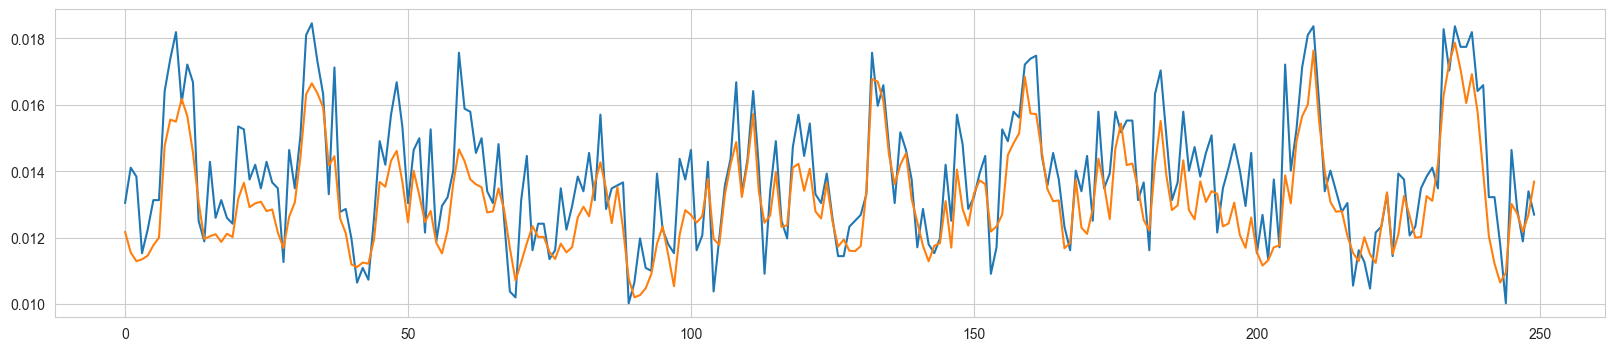

In [40]:
plt.figure(figsize=(20,4))
plt.plot(mean_spikes[0].mean(axis=1))
plt.plot(mean_rates[0].mean(axis=1))

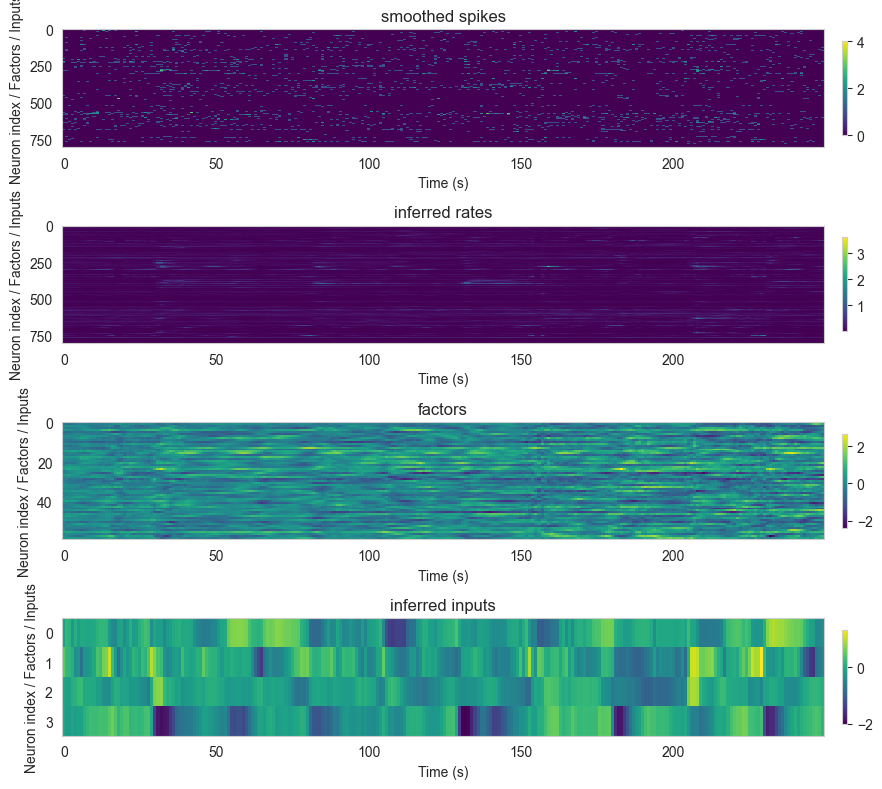

In [24]:
import matplotlib.pyplot as plt

# Visualize raw spikes, smoothed spikes, LFADS rates, and LFADS factors for a single trial
session = "v1"
trial = 2
data = {
    "smoothed spikes": spikes[session][trial],
    "inferred rates": rates[session][trial],
    "factors": factors[session][trial],
    "inferred inputs": inferred_inputs[session][trial]
}

fig, axes = plt.subplots(nrows=4, figsize=(10, 8))
for ax, (name, data_val) in zip(axes, data.items()):
    im = ax.imshow(data_val.T, aspect='auto', interpolation='none', cmap='viridis')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Neuron index / Factors / Inputs')
    ax.set_title(name)
    ax.grid(False)
    fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
plt.tight_layout()

As an additional check, we can plot the PSTHs of the LFADS rates to verify if they are comparable to the empirical PSTHs obtained using smoothed spikes.
For simplicity, we do this for a single session and 20 neurons below.

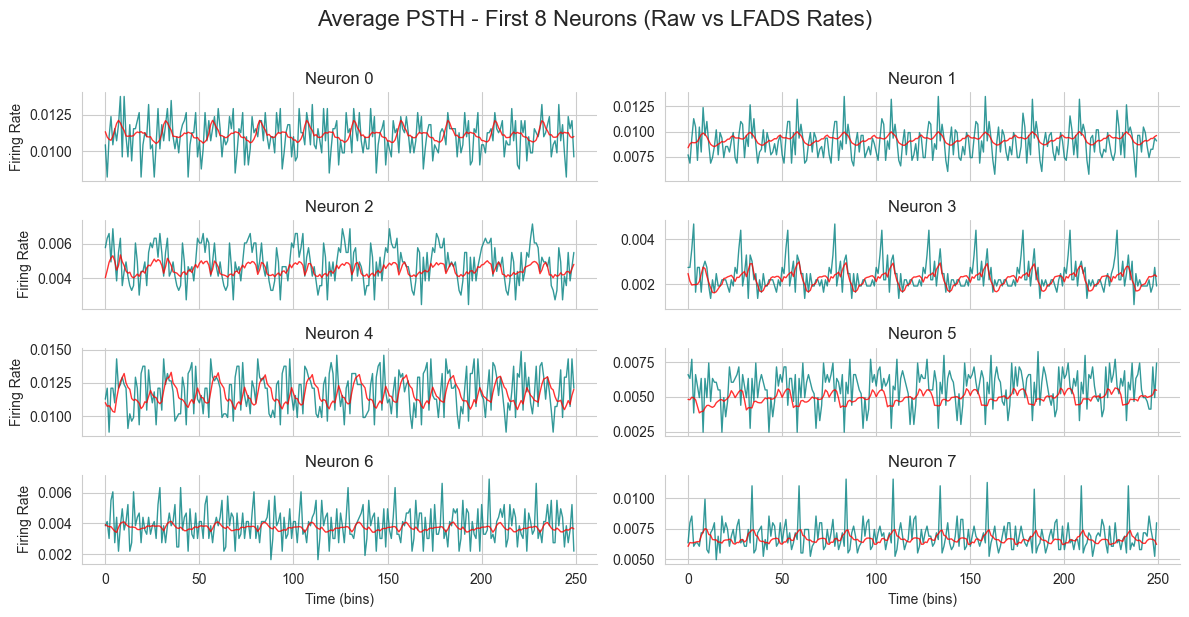

In [17]:
def plot_overlay_psths_first_8(spikes_data, rates_data, title):
    # Create a 4x2 grid to fit exactly 8 neurons
    fig, axes = plt.subplots(4, 2, figsize=(12, 6), sharex=True)
    
    # Flatten the axes array to easily iterate through all 8 subplots
    axes_flat = axes.flatten()
    
    for i in range(8):
        ax = axes_flat[i]
        
        # Calculate the mean across all trials for the i-th neuron
        spikes_mean_activity = np.mean(spikes_data[:, :, i], axis=0)
        rates_mean_activity = np.mean(rates_data[:, :, i], axis=0)
        
        ax.plot(spikes_mean_activity, color='teal', linewidth=1, alpha=0.8)
        ax.plot(rates_mean_activity, color='red', linewidth=1, alpha=0.8)
        ax.set_title(f"Neuron {i}", fontsize=12)
        
        # Clean up visual clutter
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Add labels only to the bottom-most plots for a cleaner look
        if i >= 6:
            ax.set_xlabel("Time (bins)")
        if i % 2 == 0:
            ax.set_ylabel("Firing Rate")

    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

sess = 'v1'
# Run the updated plotting function
plot_overlay_psths_first_8(spikes[sess], rates[sess], "Average PSTH - First 8 Neurons (Raw vs LFADS Rates)")

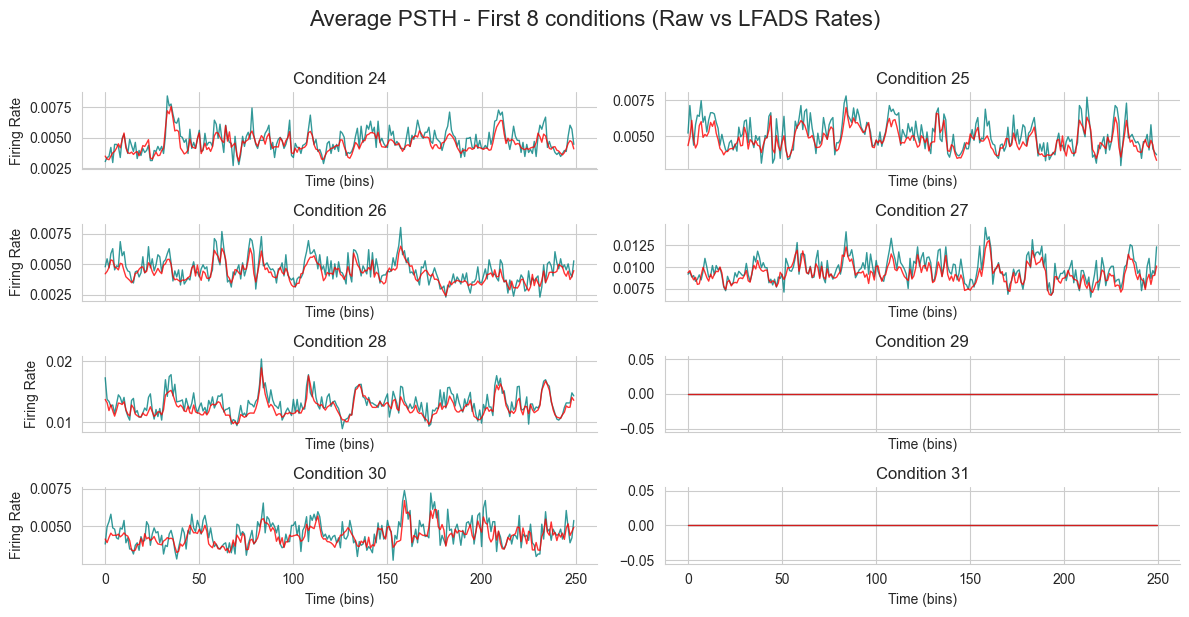

In [45]:
def plot_mean_by_condition(spikes_data, rates_data, title):
    # Create a 4x2 grid to fit exactly 8 neurons
    fig, axes = plt.subplots(4, 2, figsize=(12, 6), sharex=True)
    
    # Flatten the axes array to easily iterate through all 8 subplots
    axes_flat = axes.flatten()
    
    for i in range(24, 32):
        ax = axes_flat[i-24]
        
        # Calculate the mean across all trials for the i-th condition
        spikes_mean_activity = np.mean(spikes_data[i], axis=1)
        rates_mean_activity = np.mean(rates_data[i], axis=1)
        
        ax.plot(spikes_mean_activity, color='teal', linewidth=1, alpha=0.8)
        ax.plot(rates_mean_activity, color='red', linewidth=1, alpha=0.8)
        ax.set_title(f"Condition {i}", fontsize=12)
        
        # Clean up visual clutter
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Add labels only to the bottom-most plots for a cleaner look
        if i >= 6:
            ax.set_xlabel("Time (bins)")
        if i % 2 == 0:
            ax.set_ylabel("Firing Rate")

    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Run the updated plotting function
plot_mean_by_condition(mean_spikes, mean_rates, "Average PSTH - First 8 conditions (Raw vs LFADS Rates)")

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

ValueError: All arrays must be of the same length

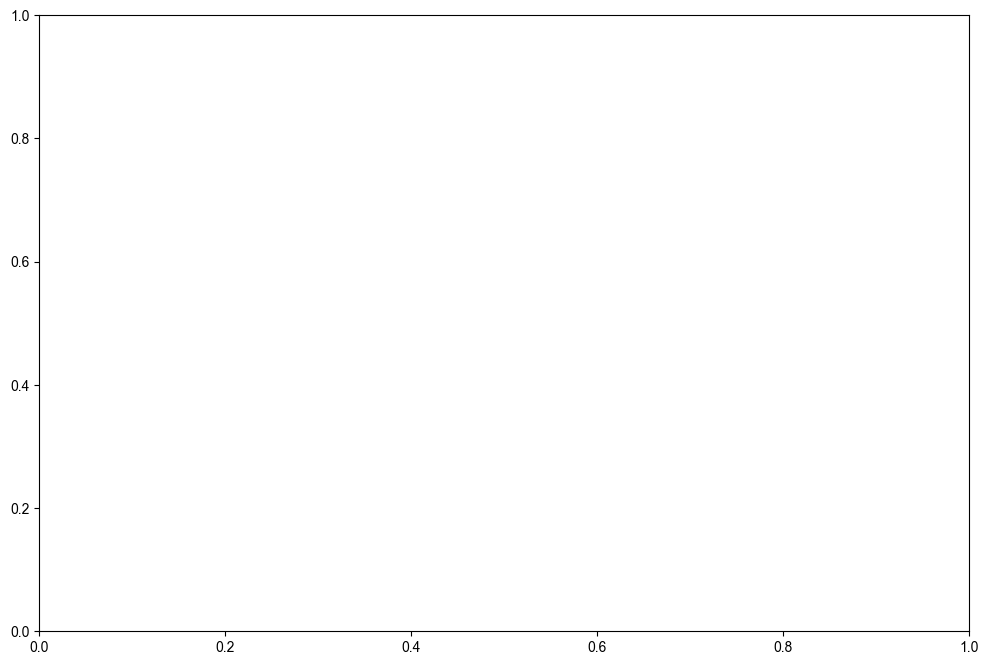

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

def plot_pca_stacked_inputs(data_array, title='PCA Projection', ax=None):
    """
    Performs PCA on reshaped (Trials, Time * Dimensions) data and plots 
    on a provided axis for subplot integration.
    """
    # 1. Reshape: (Trials, Time, Dim) --> (Trials, Time * Dim)
    n_trials, n_time, n_dim = data_array.shape
    reshaped_data = data_array.reshape(n_trials, -1)
    
    # 2. Handle Axis/Figure
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 8))
    else:
        fig = ax.get_figure()

    # 3. Define labels (Ensure they match n_trials)
    base_conditions = (
        ['Danger'] * 6 + 
        ['Uncertain Shock'] * 6 + 
        ['Uncertain No Shock'] * 10 + 
        ['Safety'] * 10
    )
    current_conditions = base_conditions[:n_trials]

    # 4. Run PCA
    pca = PCA(n_components=2)
    pca_results = pca.fit_transform(reshaped_data)
    var_explained = pca.explained_variance_ratio_ * 100

    # 5. Visualization
    sns.set_style("whitegrid")
    palette = {
        'Danger': '#e74c3c', 
        'Uncertain Shock': '#9b59b6', 
        'Uncertain No Shock': '#3498db',
        'Safety': '#2ecc71'
    }

    sns.scatterplot(
        x=pca_results[:, 0], 
        y=pca_results[:, 1], 
        hue=current_conditions,
        palette=palette,
        s=100,
        alpha=0.8,
        edgecolor='black',
        ax=ax  # This tells seaborn to use your specific subplot
    )

    ax.set_title(title, fontsize=15)
    ax.set_xlabel(f'PC 1 ({var_explained[0]:.1f}% Var)')
    ax.set_ylabel(f'PC 2 ({var_explained[1]:.1f}% Var)')
    
    # Legend handling: move it outside the plot area
    ax.legend(title='Condition', bbox_to_anchor=(1, 1), loc='upper right')
    
    return fig, ax

plot_pca_stacked_inputs(factors['v1'][:, :105, :], title="PCA projection of latent factors (post shock)")

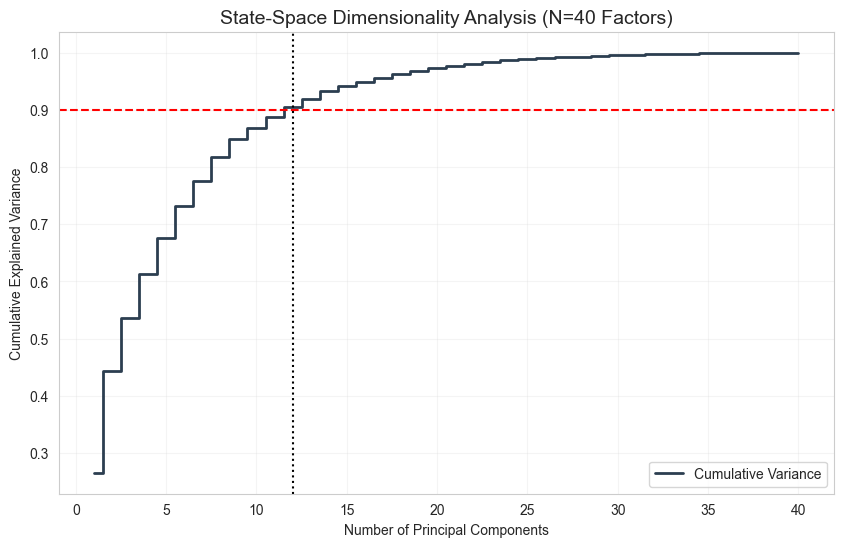

--- State-Space Analysis ---
Total Factors in Model: 40
Intrinsic Dimensionality (>90%): 12


In [10]:
def analyze_pca_variance(data_array, threshold=0.90):
    """
    Analyzes dimensionality across the 'Factors' dimension.
    data_array: (n_trials, n_timepoints, n_factors)
    """
    # 1. Reshape: Stack all trials and timepoints
    # Resulting shape: (Total_Timepoints, n_factors)
    n_trials, n_time, n_factors = data_array.shape
    state_space_data = data_array.reshape(-1, n_factors)
    
    # 2. Fit PCA on the factor dimension
    pca = PCA()
    pca.fit(state_space_data)
    
    # 3. Calculate Variance Metrics
    exp_var_ratio = pca.explained_variance_ratio_
    cumulative_var = np.cumsum(exp_var_ratio)
    
    # 4. Find threshold
    n_pcs_needed = np.argmax(cumulative_var >= threshold) + 1
    
    # 5. Plotting
    plt.figure(figsize=(10, 6))
    plt.step(range(1, len(cumulative_var) + 1), cumulative_var, where='mid',
             label='Cumulative Variance', color='#2c3e50', lw=2)


    plt.axhline(y=threshold, color='r', linestyle='--')
    plt.axvline(x=n_pcs_needed, color='black', linestyle=':')
    
    plt.title(f'State-Space Dimensionality Analysis (N={n_factors} Factors)', fontsize=14)
    plt.ylabel('Cumulative Explained Variance')
    plt.xlabel('Number of Principal Components')
    plt.xticks(range(0, n_factors + 1, 5))
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.2)
    plt.show()

    print(f"--- State-Space Analysis ---")
    print(f"Total Factors in Model: {n_factors}")
    print(f"Intrinsic Dimensionality (>{int(threshold*100)}%): {n_pcs_needed}")
    
    return n_pcs_needed

# Example usage with your LFADS factors:
results = analyze_pca_variance(factors['EAA'])

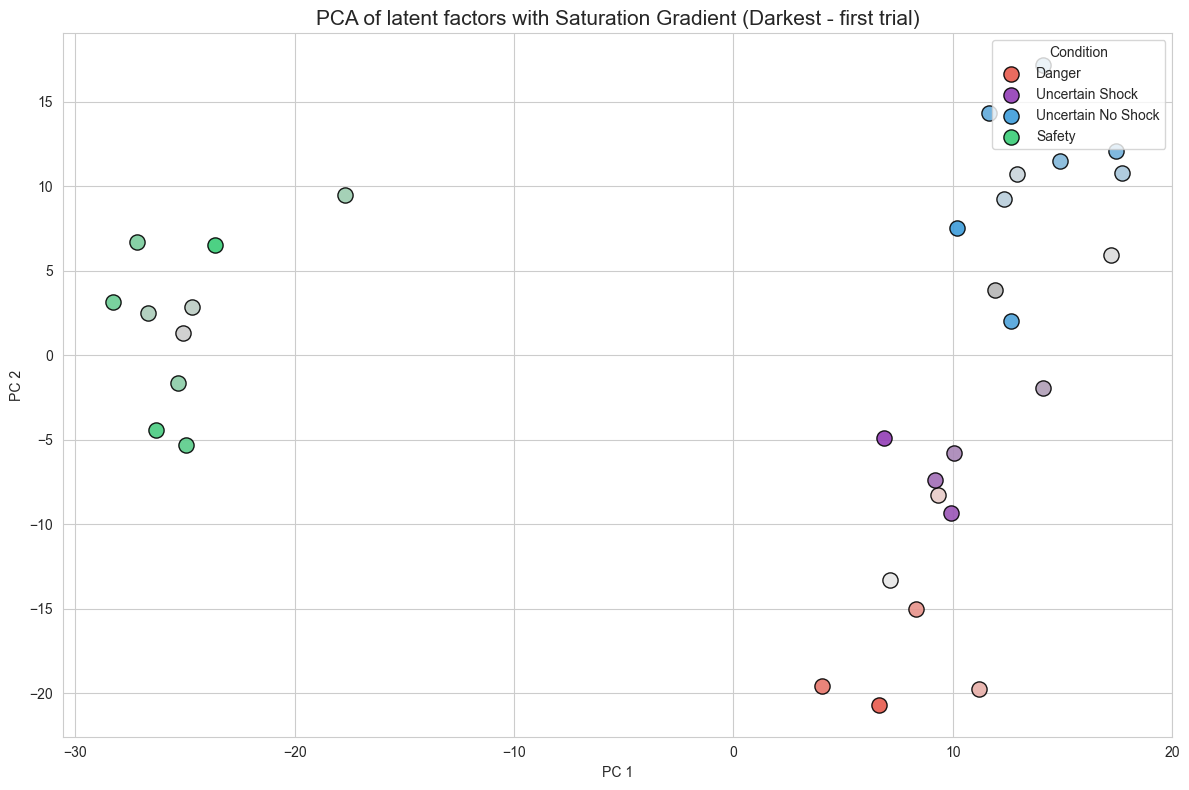

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import matplotlib.colors as mcolors
import colorsys

def plot_pca_with_saturation(data_array):
    # 1. Prepare data
    n_trials, n_time, n_inputs = data_array.shape
    reshaped_data = data_array.reshape(n_trials, -1)

    # 2. Define trial counts per condition
    condition_counts = {
        'Danger': 6,
        'Uncertain Shock': 6,
        'Uncertain No Shock': 10,
        'Safety': 10
    }
    
    # Base colors (Hex)
    base_palette = {
        'Danger': '#e74c3c',            # Red
        'Uncertain Shock': '#9b59b6',   # Purple
        'Uncertain No Shock': '#3498db',# Blue
        'Safety': '#2ecc71'             # Green
    }

    # 3. Generate labels and trial-specific colors
    labels = []
    trial_colors = []
    
    for cond, count in condition_counts.items():
        base_rgb = mcolors.to_rgb(base_palette[cond])
        # Convert RGB to HSV
        h, s, v = colorsys.rgb_to_hsv(*base_rgb)
        
        for i in range(count):
            labels.append(cond)
            saturation_level = 1 - (0.2 + (0.8 * ((i + 1) / count)))
            
            # Convert back to RGB with new saturation
            new_rgb = colorsys.hsv_to_rgb(h, saturation_level, v)
            trial_colors.append(new_rgb)

    # 4. Run PCA
    pca = PCA(n_components=2)
    pca_results = pca.fit_transform(reshaped_data)

    # 5. Visualization
    plt.figure(figsize=(12, 8))
    sns.set_style("whitegrid")

    # Plot each point individually to apply specific color
    for i in range(n_trials):
        plt.scatter(
            pca_results[i, 0], 
            pca_results[i, 1], 
            color=trial_colors[i],
            s=120, 
            edgecolor='black',
            alpha=0.9,
            label=labels[i] if labels[i] not in plt.gca().get_legend_handles_labels()[1] else ""
        )

    plt.title('PCA of latent factors with Saturation Gradient (Darkest - first trial)', fontsize=15)
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.legend(title='Condition', bbox_to_anchor=(1.00, 1), loc='upper right')
    plt.tight_layout()
    plt.show()

plot_pca_with_saturation(factors['EAA'][:, 125:, :])

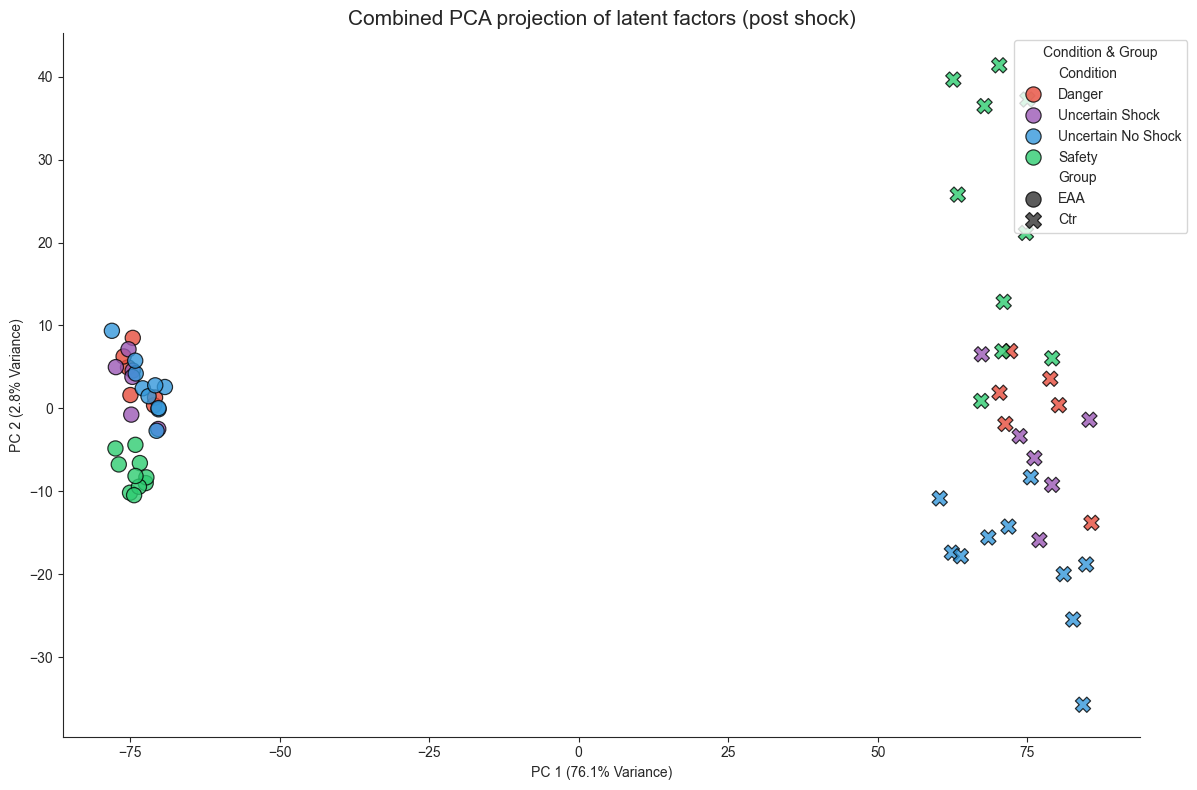

In [12]:
def plot_pca_combined(data_array_EAA, data_array_Ctr, title="Combined PCA projection of inferred inputs"):
    # 1. Flatten and Concatenate
    # Shapes: (n_trials, n_time, n_inputs) -> (n_trials, n_time * n_inputs)
    flat_EAA = data_array_EAA.reshape(data_array_EAA.shape[0], -1)
    flat_Ctr = data_array_Ctr.reshape(data_array_Ctr.shape[0], -1)
    
    # Combined data for shared PCA space
    combined_data = np.concatenate([flat_EAA, flat_Ctr], axis=0)

    # 2. Define labels (Conditions and Groups)
    # Adjust counts based on your trial structure
    single_session_conditions = (
        ['Danger'] * 6 + 
        ['Uncertain Shock'] * 6 + 
        ['Uncertain No Shock'] * 10 + 
        ['Safety'] * 10
    )
    
    all_conditions = single_session_conditions + single_session_conditions
    groups = ['EAA'] * len(single_session_conditions) + ['Ctr'] * len(single_session_conditions)

    # 3. Run PCA on the combined dataset
    pca = PCA(n_components=10)
    pca_results = pca.fit_transform(combined_data)
    var_expl = pca.explained_variance_ratio_ * 100

    # 4. Create DataFrame for Seaborn
    import pandas as pd
    df = pd.DataFrame({
        'PC1': pca_results[:, 0],
        'PC2': pca_results[:, 1],
        'Condition': all_conditions,
        'Group': groups
    })

    # 5. Visualization
    plt.figure(figsize=(12, 8))
    sns.set_style("ticks")
    
    palette = {
        'Danger': '#e74c3c', 
        'Uncertain Shock': '#9b59b6', 
        'Uncertain No Shock': '#3498db',
        'Safety': '#2ecc71'
    }

    sns.scatterplot(
        data=df,
        x='PC1', 
        y='PC2', 
        hue='Condition',
        style='Group', # Different shapes for EAA and Ctr
        palette=palette,
        s=120,
        alpha=0.8,
        edgecolor='black'
    )

    plt.title(title, fontsize=15)
    plt.xlabel(f'PC 1 ({var_expl[0]:.1f}% Variance)')
    plt.ylabel(f'PC 2 ({var_expl[1]:.1f}% Variance)')
    plt.legend(title='Condition & Group', bbox_to_anchor=(1.05, 1), loc='upper right')
    sns.despine()
    plt.tight_layout()
    plt.show()

# Run the combined PCA
plot_pca_combined(factors['EAA'][:, 125:, :], factors['Ctr'][:, 125:, :], 'Combined PCA projection of latent factors (post shock)')

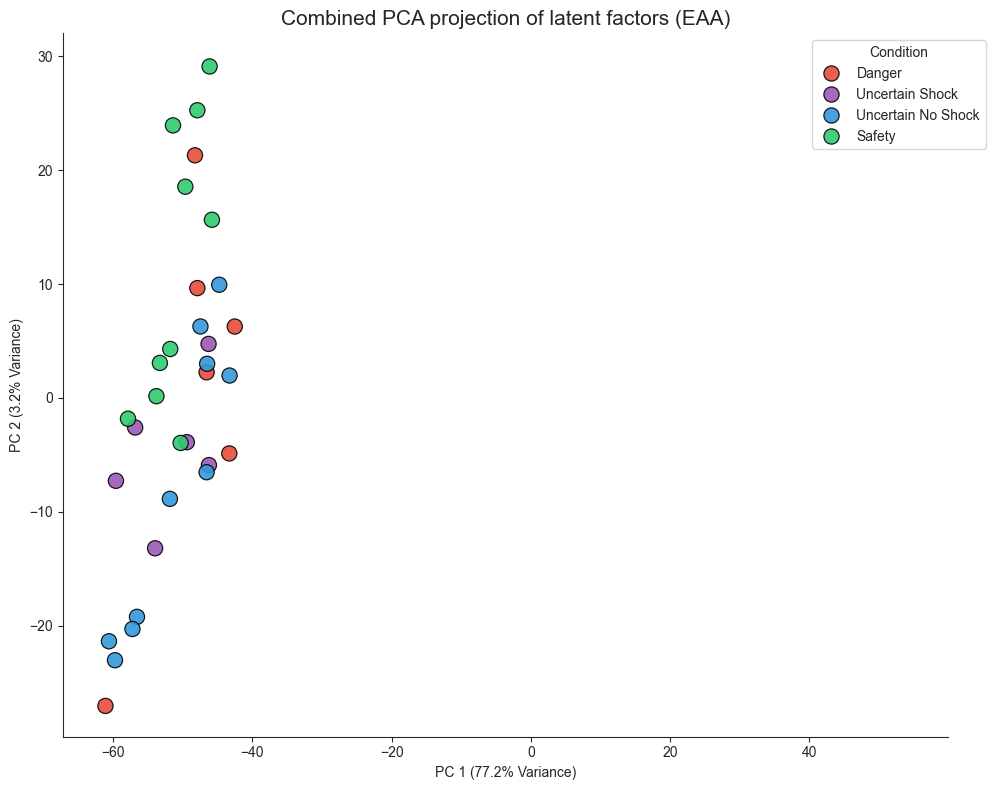

In [13]:
def plot_pca(data_array_EAA, data_array_Ctr, title="PCA projection (EAA only, Shared Space)", group='EAA'):
    # 1. Flatten and Concatenate (Shared Space calculation)
    flat_EAA = data_array_EAA.reshape(data_array_EAA.shape[0], -1)
    flat_Ctr = data_array_Ctr.reshape(data_array_Ctr.shape[0], -1)
    combined_data = np.concatenate([flat_EAA, flat_Ctr], axis=0)

    # 2. Define labels
    single_session_conditions = (
        ['Danger'] * 6 + ['Uncertain Shock'] * 6 + 
        ['Uncertain No Shock'] * 10 + ['Safety'] * 10
    )
    all_conditions = single_session_conditions + single_session_conditions
    groups = ['EAA'] * len(single_session_conditions) + ['Ctr'] * len(single_session_conditions)

    # 3. Run PCA on the COMBINED dataset
    pca = PCA(n_components=2)
    pca_results = pca.fit_transform(combined_data)
    var_expl = pca.explained_variance_ratio_ * 100

    # 4. Create DataFrame
    import pandas as pd
    df = pd.DataFrame({
        'PC1': pca_results[:, 0],
        'PC2': pca_results[:, 1],
        'Condition': all_conditions,
        'Group': groups
    })

    # --- NEW: Filter for EAA only ---
    df_plot = df[df['Group'] == group]

    # 5. Visualization
    plt.figure(figsize=(10, 8))
    sns.set_style("ticks")
    
    palette = {
        'Danger': '#e74c3c', 'Uncertain Shock': '#9b59b6', 
        'Uncertain No Shock': '#3498db', 'Safety': '#2ecc71'
    }

    # Plot using the filtered dataframe
    sns.scatterplot(
        data=df_plot,
        x='PC1', 
        y='PC2', 
        hue='Condition',
        palette=palette,
        s=120,        # Made markers slightly larger since there's less clutter
        alpha=0.9,
        edgecolor='black'
    )

    # Set axis limits based on the COMBINED data so the scale doesn't "zoom in"
    # This keeps the perspective of where EAA sits relative to Ctr
    plt.xlim(df['PC1'].min() * 1.1, df['PC1'].max() * 1.1)
    plt.ylim(df['PC2'].min() * 1.1, df['PC2'].max() * 1.1)

    plt.title(title, fontsize=15)
    plt.xlabel(f'PC 1 ({var_expl[0]:.1f}% Variance)')
    plt.ylabel(f'PC 2 ({var_expl[1]:.1f}% Variance)')
    plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper right')
    sns.despine()
    plt.tight_layout()
    plt.show()

plot_pca(factors['EAA'][:, :105, :], factors['Ctr'][:, :105, :], 'Combined PCA projection of latent factors (EAA)', group='Ctr')

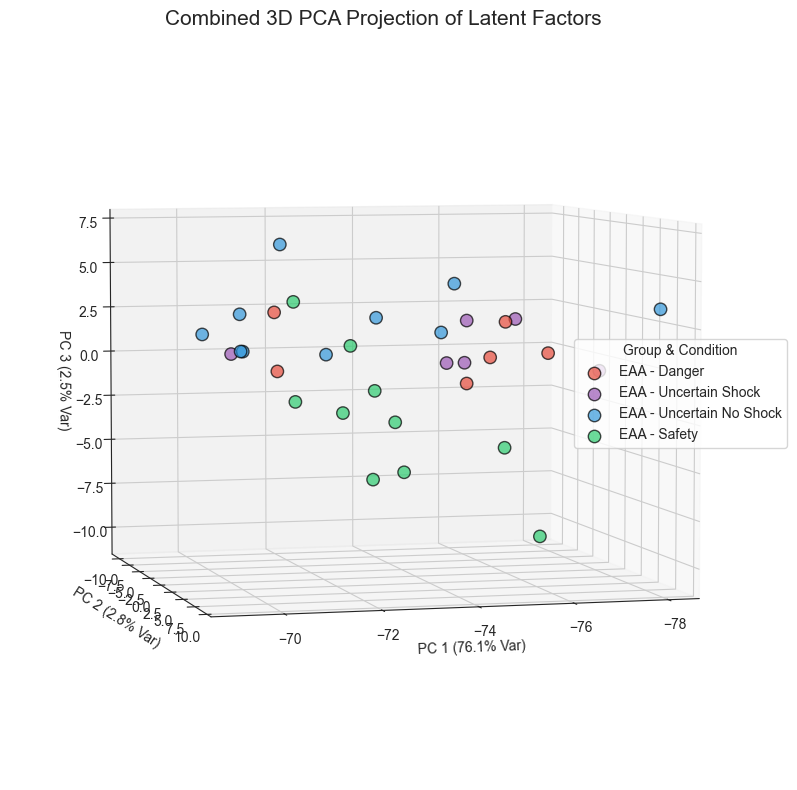

In [14]:
def plot_pca_combined_3d(data_array_EAA, data_array_Ctr, title="Combined 3D PCA projection", elev=10, azim=135, show_group='both', ax=None):
    # 1. Flatten and Concatenate
    flat_EAA = data_array_EAA.reshape(data_array_EAA.shape[0], -1)
    flat_Ctr = data_array_Ctr.reshape(data_array_Ctr.shape[0], -1)
    combined_data = np.concatenate([flat_EAA, flat_Ctr], axis=0)

    # 2. Define labels
    single_session_conditions = (
        ['Danger'] * 6 + 
        ['Uncertain Shock'] * 6 + 
        ['Uncertain No Shock'] * 10 + 
        ['Safety'] * 10
    )
    all_conditions = single_session_conditions + single_session_conditions
    groups = ['EAA'] * len(single_session_conditions) + ['Control'] * len(single_session_conditions)

    # 3. Run PCA for 3 components
    pca = PCA(n_components=3)
    pca_results = pca.fit_transform(combined_data)
    var_expl = pca.explained_variance_ratio_ * 100

    # 4. Visualization Setup
    if ax is None:
            fig = plt.figure(figsize=(10, 8))
            ax = fig.add_subplot(111, projection='3d')
    
    palette = {
        'Danger': '#e74c3c', 
        'Uncertain Shock': '#9b59b6', 
        'Uncertain No Shock': '#3498db',
        'Safety': '#2ecc71'
    }
    
    # Map markers to Groups (Circle for EAA, Square/X for Ctr)
    markers = {'EAA': 'o', 'Ctr': 'X'}

    groups_to_plot = ['EAA', 'Ctr'] if show_group == 'both' else [show_group]

    # 5. Plotting points individually to handle hue/style manually
    for group in groups_to_plot:
        for condition in palette.keys():
            # Create a mask for rows matching this group and condition
            mask = (np.array(groups) == group) & (np.array(all_conditions) == condition)
            
            if np.any(mask):
                ax.scatter(
                    pca_results[mask, 0], 
                    pca_results[mask, 1], 
                    pca_results[mask, 2],
                    label=f"{group} - {condition}",
                    color=palette[condition],
                    marker=markers[group],
                    s=80,
                    edgecolor='black',
                    alpha=0.7
                )

    # Labeling
    ax.set_title(title, fontsize=15)
    ax.set_xlabel(f'PC 1 ({var_expl[0]:.1f}% Var)')
    ax.set_ylabel(f'PC 2 ({var_expl[1]:.1f}% Var)')
    ax.set_zlabel(f'PC 3 ({var_expl[2]:.1f}% Var)')
    
    # Legend - placing it outside the plot
    ax.legend(title='Group & Condition', bbox_to_anchor=(1.05, 0.6), loc='upper right')
    ax.view_init(elev=elev, azim=azim)
    plt.tight_layout()
    plt.show()

# Run the 3D PCA
plot_pca_combined_3d(factors['EAA'][:, 125:, :], factors['Ctr'][:, 125:, :], 'Combined 3D PCA Projection of Latent Factors', elev=5, azim=75, show_group='EAA')

In [15]:
def plot_pca_on_ax(pca_results, groups, all_conditions, var_expl, 
                   show_group='both', elev=10, azim=135, ax=None, use_size_gradient=False):
    palette = {
        'Danger': '#e74c3c', 'Uncertain Shock': '#9b59b6', 
        'Uncertain No Shock': '#3498db', 'Safety': '#2ecc71'
    }
    markers = {'EAA': 'o', 'Ctr': 'X'}
    
    groups_to_plot = ['EAA', 'Ctr'] if show_group == 'both' else [show_group]

    for group in groups_to_plot:
        for condition in palette.keys():
            mask = (np.array(groups) == group) & (np.array(all_conditions) == condition)
            
            if np.any(mask):
                if use_size_gradient:
                    # Number of trials in this specific group/condition combo
                    n_subset = np.sum(mask)
                    # Create a linear ramp from 20 to 50 based on the count of THIS subset
                    # If there's only 1 trial, it will default to the start size (20)
                    if n_subset > 1:
                        sizes = np.linspace(20, 50, n_subset)
                    else:
                        sizes = [30]
                else:
                    sizes = 30 

                ax.scatter(
                    pca_results[mask, 0], pca_results[mask, 1], pca_results[mask, 2],
                    label=f"{group} - {condition}",
                    color=palette[condition], marker=markers[group],
                    s=sizes, edgecolor='grey', alpha=0.8
                )

    # Consistent limits and labeling
    ax.set_xlim(pca_results[:, 0].min(), pca_results[:, 0].max())
    ax.set_ylim(pca_results[:, 1].min(), pca_results[:, 1].max())
    ax.set_zlim(pca_results[:, 2].min(), pca_results[:, 2].max())
    ax.tick_params(axis='both', which='major', labelsize=9, pad=-2)
    ax.tick_params(axis='z', labelsize=9)
    ax.set_xlabel(f'PC1 ({var_expl[0]:.1f}%)', labelpad=-2, fontsize=9)
    ax.set_ylabel(f'PC2 ({var_expl[1]:.1f}%)', labelpad=-2, fontsize=9)
    ax.set_zlabel(f'PC3 ({var_expl[2]:.1f}%)', labelpad=-2, fontsize=9)
    ax.view_init(elev=elev, azim=azim)

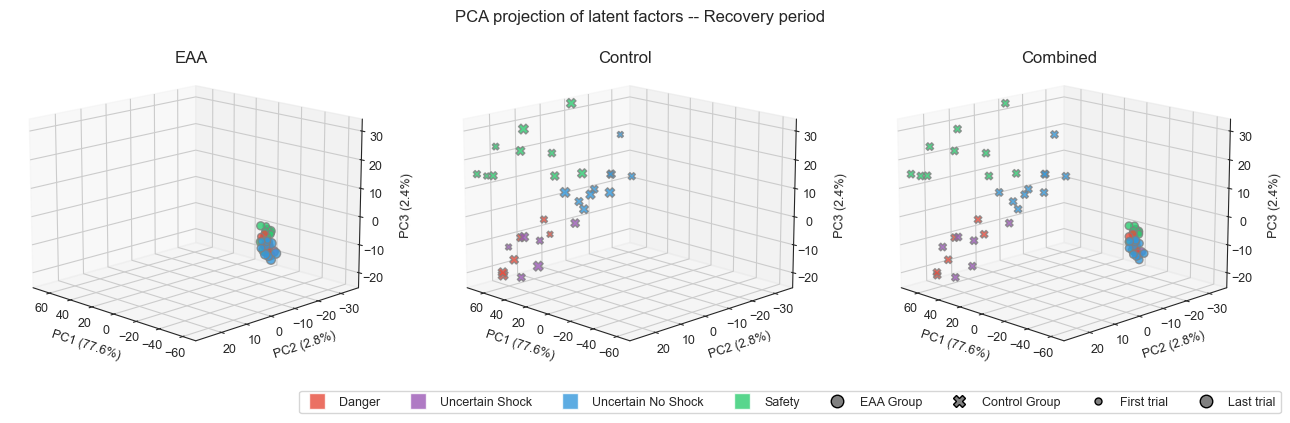

In [16]:
from matplotlib.lines import Line2D

def plot_pca_tri_panel(data_array_EAA, data_array_Ctr, title, elev=15, azim=135):
    # 1. Shared PCA Calculation
    flat_EAA = data_array_EAA.reshape(data_array_EAA.shape[0], -1)
    flat_Ctr = data_array_Ctr.reshape(data_array_Ctr.shape[0], -1)
    combined_data = np.concatenate([flat_EAA, flat_Ctr], axis=0)
    
    pca = PCA(n_components=3)
    pca_results = pca.fit_transform(combined_data)
    var_expl = pca.explained_variance_ratio_ * 100

    # 2. Shared Labels
    single_conds = ['Danger']*6 + ['Uncertain Shock']*6 + ['Uncertain No Shock']*10 + ['Safety']*10
    all_conditions = single_conds + single_conds
    groups = ['EAA']*len(single_conds) + ['Ctr']*len(single_conds)

    # 3. Create Figure
    fig = plt.figure(figsize=(30, 10))

    # Subplot 1: EAA
    ax1 = fig.add_subplot(131, projection='3d')
    plot_pca_on_ax(pca_results, groups, all_conditions, var_expl, 
                   show_group='EAA', ax=ax1, elev=elev, azim=azim, use_size_gradient=True)
    ax1.set_title('EAA', fontsize=12, y=0.96)

    # Subplot 2: Ctr
    ax2 = fig.add_subplot(132, projection='3d')
    plot_pca_on_ax(pca_results, groups, all_conditions, var_expl, 
                   show_group='Ctr', ax=ax2, elev=elev, azim=azim, use_size_gradient=True)
    ax2.set_title('Control', fontsize=12, y=0.96)

    # Subplot 3: Combined
    ax3 = fig.add_subplot(133, projection='3d')
    plot_pca_on_ax(pca_results, groups, all_conditions, var_expl, 
                   show_group='both', ax=ax3, elev=elev, azim=azim)
    ax3.set_title('Combined', fontsize=12, y=0.96)



    palette = {'Danger': '#e74c3c', 'Uncertain Shock': '#9b59b6', 
               'Uncertain No Shock': '#3498db', 'Safety': '#2ecc71'}
    
    # Part A: Condition Handles (using lines or squares)
    condition_elements = [Line2D([0], [0], marker='s', color='w', label=k,
                                 markerfacecolor=v, markersize=12, alpha=0.8) 
                          for k, v in palette.items()]
    
    # Part B: Group Handles (using markers with neutral color)
    group_elements = [
        Line2D([0], [0], marker='o', color='w', label='EAA Group',
               markerfacecolor='gray', markersize=9, markeredgecolor='black'),
        Line2D([0], [0], marker='X', color='w', label='Control Group',
               markerfacecolor='gray', markersize=9, markeredgecolor='black')
    ]

    trial_elements = [
        Line2D([0], [0], marker='o', color='w', label='First trial',
               markerfacecolor='gray', markersize=5, markeredgecolor='black'),
        Line2D([0], [0], marker='o', color='w', label='Last trial',
               markerfacecolor='gray', markersize=9, markeredgecolor='black')
    ]

    # Combine them
    all_handles = condition_elements + group_elements + trial_elements

    # Global Legend
    # handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles=all_handles, loc='lower center', ncol=8, bbox_to_anchor=(0.28, 0.34), fontsize=9)
    
    plt.subplots_adjust(
    left=0.02,    # Space on the left
    right=0.43,   # Space on the right
    bottom=0.1,  # Space at bottom (leave room for the legend!)
    top=1.0,      # Space at top
    )

    plt.suptitle(title, x=0.23, y=0.75)
    plt.show()

# Run it
plot_pca_tri_panel(factors['EAA'][:, 170:, :], factors['Ctr'][:, 170:, :], title='PCA projection of latent factors -- Recovery period')

In [17]:
len(factors['EAA'])

32

r [-0.20620412647256706, 0.006892414718949011, 0.3156805797750746, -0.40977845799940116, -0.06500745891077236, 0.036585073559855644, -0.11526792222791246, 0.04470323178044404, 0.11095628224828082, -0.14617172012248542]
p [0.25751726759895854, 0.9701353543351156, 0.0784026481601671, 0.01985026670339017, 0.7237277312893694, 0.842427953725968, 0.5298658779574882, 0.8080519494756262, 0.5454694944460745, 0.4247105510338052]


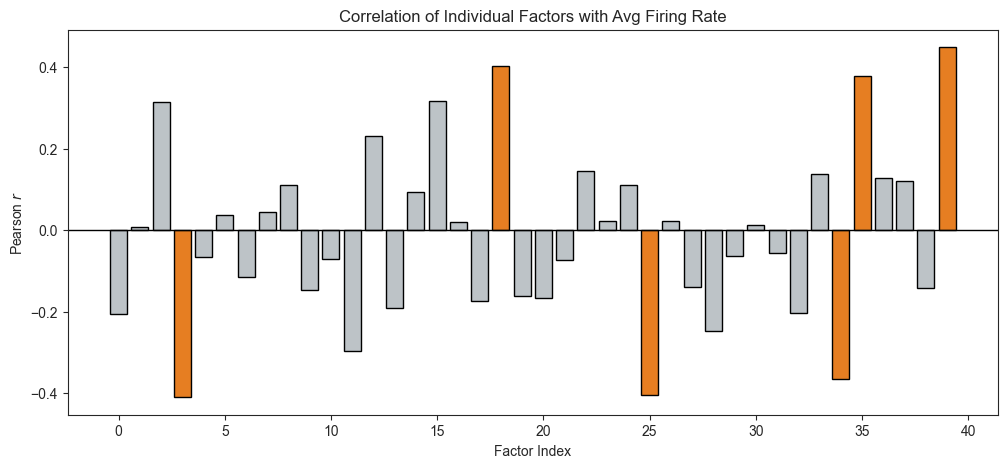

[-0.20620412647256706,
 0.006892414718949011,
 0.3156805797750746,
 -0.40977845799940116,
 -0.06500745891077236,
 0.036585073559855644,
 -0.11526792222791246,
 0.04470323178044404,
 0.11095628224828082,
 -0.14617172012248542,
 -0.07030140820048661,
 -0.2958404384292125,
 0.23029959157064178,
 -0.19016652808640505,
 0.0947094279065576,
 0.31757919763756615,
 0.02048661988619102,
 -0.17272886775416116,
 0.4037407563846121,
 -0.1624036105857719,
 -0.16752963175161303,
 -0.07373597238022472,
 0.14555421587084227,
 0.02145992869470713,
 0.10987713120534329,
 -0.4031943739987318,
 0.023692638851025433,
 -0.13818992705065009,
 -0.24696628778170104,
 -0.06309372252135227,
 0.012376894025122945,
 -0.056838270138710324,
 -0.2036812637891962,
 0.13672941940184133,
 -0.36432853389346587,
 0.37854398548572776,
 0.12738427766601654,
 0.12188014509838511,
 -0.14218108064434412,
 0.4489480932070407]

In [18]:
from scipy import stats
def check_factor_firing_rate_correlation(raw_data, latent_factors):
    """
    Correlates each individual latent factor with the trial-averaged raw firing rate.
    """
    n_trials, n_time, n_factors = latent_factors.shape
    
    # 1. Calculate trial-average firing rate (same as before)
    avg_firing_rates = np.mean(raw_data, axis=(1, 2))
    
    # 2. Average each factor across time to get one value per trial
    # This gives us a (n_trials, n_factors) matrix
    trial_factor_means = np.mean(latent_factors, axis=1)
    
    correlations = []
    p_values = []
    
    # 3. Correlate each individual factor with the raw rate
    for i in range(n_factors):
        r, p = stats.pearsonr(trial_factor_means[:, i], avg_firing_rates)
        correlations.append(r)
        p_values.append(p)
    
    print("r", correlations[0:10])
    print("p", p_values[0:10])
    
    # 4. Plotting
    plt.figure(figsize=(12, 5))
    colors = ['#e67e22' if p < 0.05 else '#bdc3c7' for p in p_values]
    
    plt.bar(range(n_factors), correlations, color=colors, edgecolor='black')
    plt.axhline(0, color='black', lw=1)
    plt.title("Correlation of Individual Factors with Avg Firing Rate")
    plt.xlabel("Factor Index")
    plt.ylabel("Pearson $r$")
    plt.show()

    return correlations

check_factor_firing_rate_correlation(spikes['EAA'], factors['EAA'])

# Inferred inputs analysis

### plot inferred inputs, EAA vs control

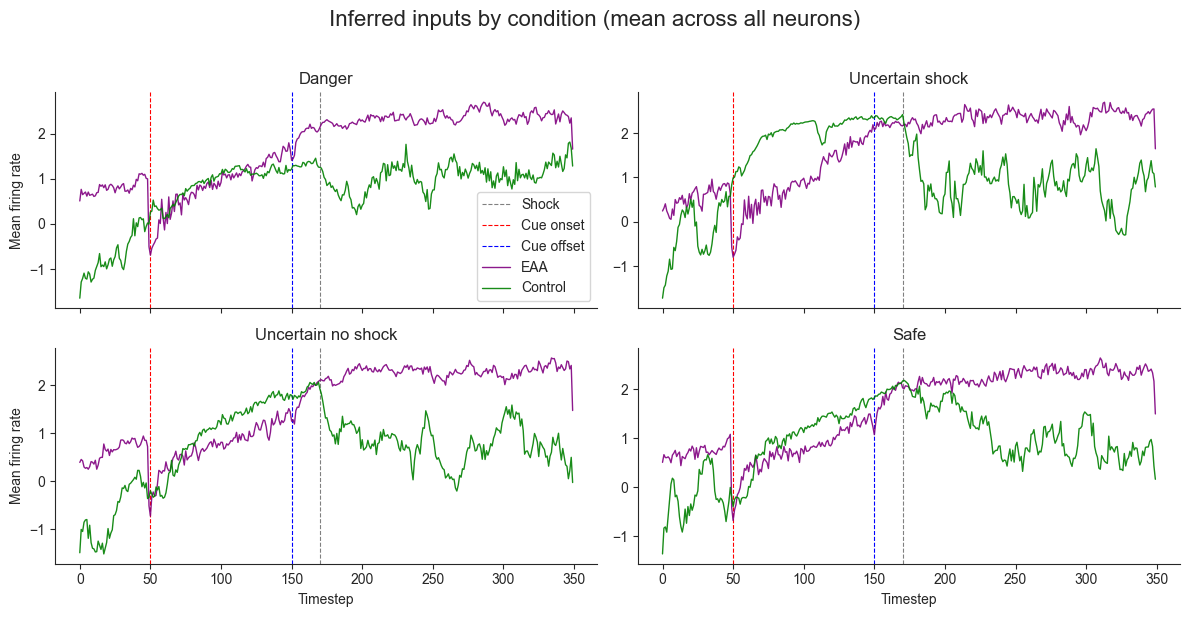

In [19]:
# plot inferred inputs for each condition

def plot_inferred_inputs_by_group(input_data_EAA, input_data_Ctr, title):
    # Create a 2x2 grid to fit exactly 4 conditions
    fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
    conditions = ['Danger', 'Uncertain shock', 'Uncertain no shock', 'Safe']
    
    # Flatten the axes array to easily iterate through all 4 subplots
    axes_flat = axes.flatten()

    inputs_EAA_danger = np.mean(input_data_EAA[0:4, :, :], axis=(0, 2))
    inputs_EAA_unc_noshock = np.mean(input_data_EAA[4:6, :, :], axis=(0, 2))
    inputs_EAA_unc_shock = np.mean(input_data_EAA[6:11, :, :], axis=(0, 2))
    inputs_EAA_safety = np.mean(input_data_EAA[11:15, :, :], axis=(0, 2))
    inputs_EAA = [inputs_EAA_danger, inputs_EAA_unc_noshock, inputs_EAA_unc_shock, inputs_EAA_safety]

    inputs_Ctr_danger = np.mean(input_data_Ctr[0:4, :, :], axis=(0, 2))
    inputs_Ctr_unc_noshock = np.mean(input_data_Ctr[4:6, :, :], axis=(0, 2))
    inputs_Ctr_unc_shock = np.mean(input_data_Ctr[6:11, :, :], axis=(0, 2))
    inputs_Ctr_safety = np.mean(input_data_Ctr[11:15, :, :], axis=(0, 2))
    inputs_Ctr = [inputs_Ctr_danger, inputs_Ctr_unc_noshock, inputs_Ctr_unc_shock, inputs_Ctr_safety]
    
    for i in range(4):
        ax = axes_flat[i]
        ax.axvline(x=170, label='Shock', color='grey', linestyle='--', linewidth=0.8)
        ax.axvline(x=50, label='Cue onset', color='red', linestyle='--', linewidth=0.8)
        ax.axvline(x=150, label='Cue offset', color='blue', linestyle='--', linewidth=0.8)
        ax.plot(inputs_EAA[i], color='purple', linewidth=1, alpha=0.9, label='EAA')
        ax.plot(inputs_Ctr[i], color='green', linewidth=1, alpha=0.9, label='Control')
        ax.set_title(conditions[i], fontsize=12)
        
        if i == 0:
            ax.legend()
        
        # Clean up visual clutter
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Add labels only to the bottom-most plots for a cleaner look
        if i >= 2:
            ax.set_xlabel("Timestep")
        if i % 2 == 0:
            ax.set_ylabel("Mean firing rate")

    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Run the updated plotting function
plot_inferred_inputs_by_group(inferred_inputs['EAA'], inferred_inputs['Ctr'], "Inferred inputs by condition (mean across all neurons)")

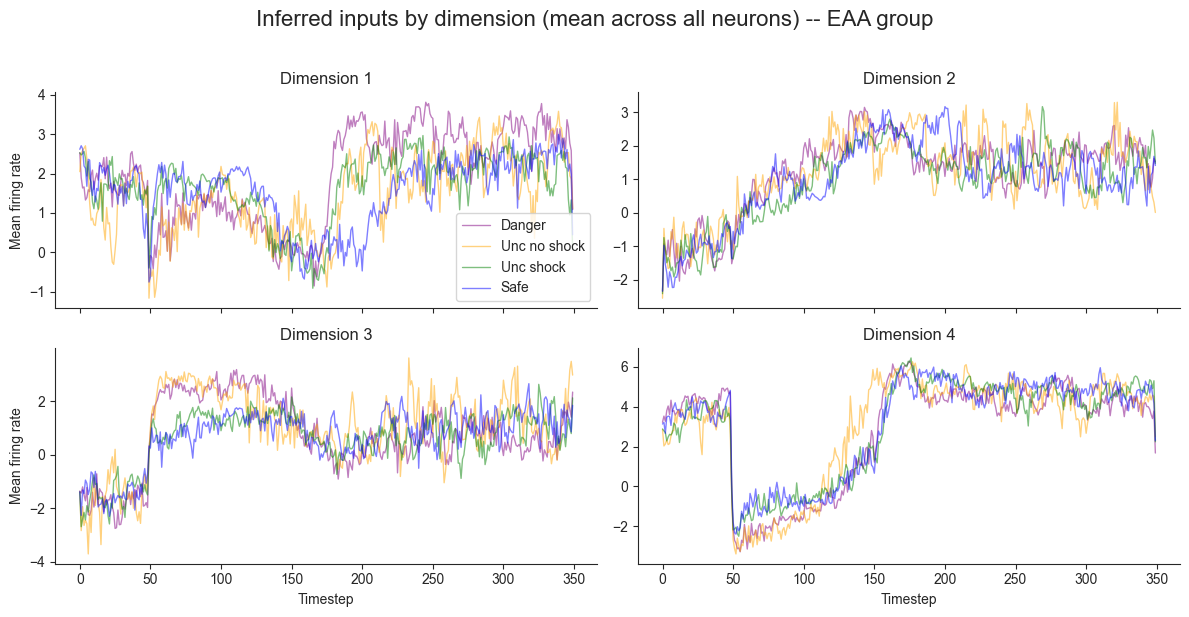

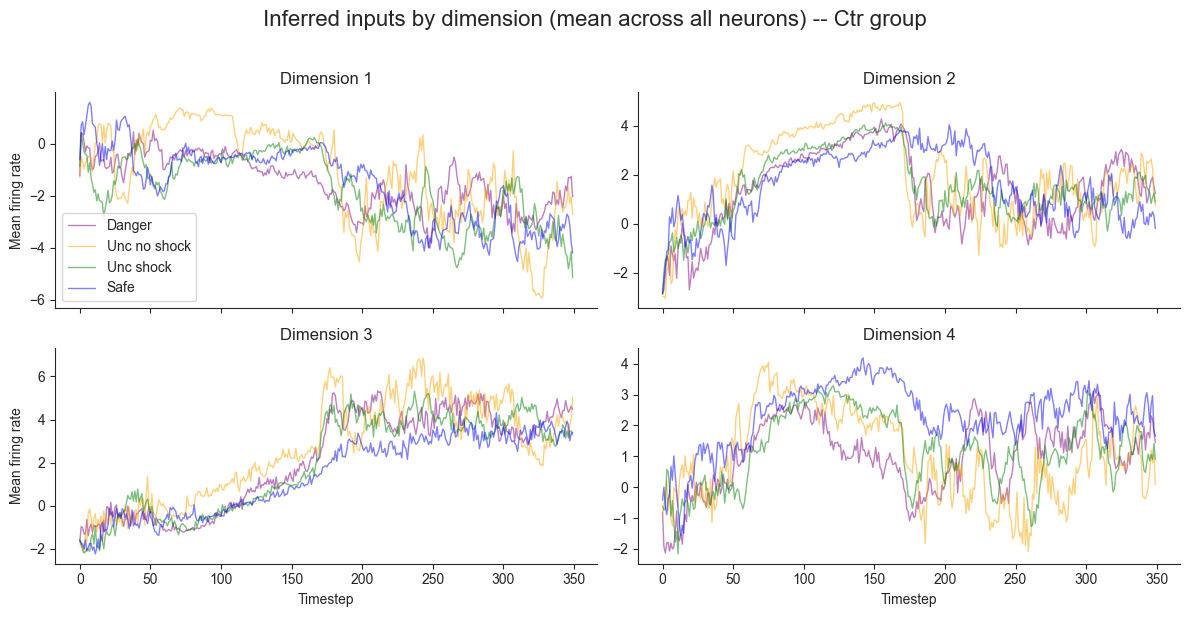

In [20]:
# plot 4 conditions for each dimension of inferred inputs

def plot_inferred_inputs_by_dimension(input_data, title):
    # Create a 2x2 grid to fit exactly 4 dimensions
    fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
    dimensions = ['Dimension 1', 'Dimension 2', 'Dimension 3', 'Dimension 4']
    
    # Flatten the axes array to easily iterate through all 4 subplots
    axes_flat = axes.flatten()

    inputs_dim0_danger = np.mean(input_data[0:4, :, 0:1], axis=0)
    inputs_dim0_unc_noshock = np.mean(input_data[4:6, :, 0:1], axis=0)
    inputs_dim0_unc_shock = np.mean(input_data[6:11, :, 0:1], axis=0)
    inputs_dim0_safety = np.mean(input_data[11:15, :, 0:1], axis=0)

    inputs_dim1_danger = np.mean(input_data[0:4, :, 1:2], axis=0)
    inputs_dim1_unc_noshock = np.mean(input_data[4:6, :, 1:2], axis=0)
    inputs_dim1_unc_shock = np.mean(input_data[6:11, :, 1:2], axis=0)
    inputs_dim1_safety = np.mean(input_data[11:15, :, 1:2], axis=0)

    inputs_dim2_danger = np.mean(input_data[0:4, :, 2:3], axis=0)
    inputs_dim2_unc_noshock = np.mean(input_data[4:6, :, 2:3], axis=0)
    inputs_dim2_unc_shock = np.mean(input_data[6:11, :, 2:3], axis=0)
    inputs_dim2_safety = np.mean(input_data[11:15, :, 2:3], axis=0)

    inputs_dim3_danger = np.mean(input_data[0:4, :, 3:4], axis=0)
    inputs_dim3_unc_noshock = np.mean(input_data[4:6, :, 3:4], axis=0)
    inputs_dim3_unc_shock = np.mean(input_data[6:11, :, 3:4], axis=0)
    inputs_dim3_safety = np.mean(input_data[11:15, :, 3:4], axis=0)

    danger = [inputs_dim0_danger, inputs_dim1_danger, inputs_dim2_danger, inputs_dim3_danger]
    unc_noshock = [inputs_dim0_unc_noshock, inputs_dim1_unc_noshock, inputs_dim2_unc_noshock, inputs_dim3_unc_noshock]
    unc_shock = [inputs_dim0_unc_shock, inputs_dim1_unc_shock, inputs_dim2_unc_shock, inputs_dim3_unc_shock]
    safety = [inputs_dim0_safety, inputs_dim1_safety, inputs_dim2_safety, inputs_dim3_safety]

    for i in range(4):
        ax = axes_flat[i]
        
        ax.plot(danger[i], color='purple', linewidth=1, alpha=0.5, label='Danger')
        ax.plot(unc_noshock[i], color='orange', linewidth=1, alpha=0.5, label='Unc no shock')
        ax.plot(unc_shock[i], color='green', linewidth=1, alpha=0.5, label='Unc shock')
        ax.plot(safety[i], color='blue', linewidth=1, alpha=0.5, label='Safe')
        ax.set_title(dimensions[i], fontsize=12)
        
        if i == 0:
            ax.legend()
        
        # Clean up visual clutter
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Add labels only to the bottom-most plots for a cleaner look
        if i >= 2:
            ax.set_xlabel("Timestep")
        if i % 2 == 0:
            ax.set_ylabel("Mean firing rate")

    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Run the updated plotting function
plot_inferred_inputs_by_dimension(inferred_inputs['EAA'], "Inferred inputs by dimension (mean across all neurons) -- EAA group")
plot_inferred_inputs_by_dimension(inferred_inputs['Ctr'], "Inferred inputs by dimension (mean across all neurons) -- Ctr group")

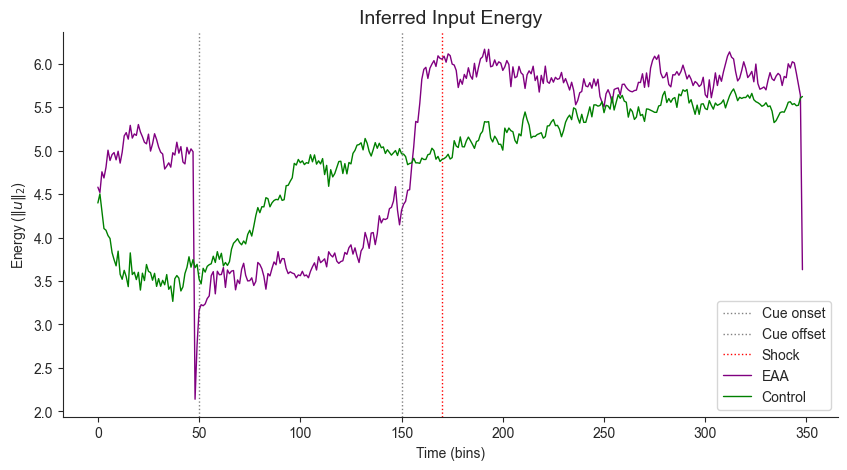

In [21]:
def plot_input_energy(inputs_EAA, inputs_Ctr, title="Inferred Input Energy", axes=None):
    """
    Calculates and plots the L2 norm (energy) of inferred inputs over time.
    
    Parameters:
        inputs: np.array of shape (n_trials, n_time, n_inputs)
        title: string for the plot title
        axes: optional matplotlib axis for subplot integration
    """
    # 1. Calculate Energy: Square the inputs, sum across dimensions, then sqrt
    # shape results in (n_trials, n_time)
    energy_EAA = np.linalg.norm(inputs_EAA, axis=2)
    energy_Ctr = np.linalg.norm(inputs_Ctr, axis=2)
    
    # 2. Calculate mean and standard error across trials
    mean_energy_EAA = np.mean(energy_EAA, axis=0)
    mean_energy_Ctr = np.mean(energy_Ctr, axis=0)
    time_points = np.arange(inputs_EAA.shape[1])

    # 3. Plotting
    if axes is None:
        fig, ax = plt.subplots(figsize=(10, 5))
    else:
        ax = axes

    ax.axvline(50, color='grey', linestyle=':', linewidth=1, label='Cue onset')
    ax.axvline(150, color='grey', linestyle=':', linewidth=1, label='Cue offset')
    ax.axvline(170, color='red', linestyle=':', linewidth=1, label='Shock')
    ax.plot(time_points, mean_energy_EAA, color='purple', lw=1, label='EAA')
    ax.plot(time_points, mean_energy_Ctr, color='green', lw=1, label='Control')


    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Time (bins)")
    ax.set_ylabel("Energy ($\|u\|_2$)")
    ax.legend()
    sns.despine(ax=ax)
    
    if axes is None:
        plt.show()

# Example usage:
plot_input_energy(inferred_inputs['EAA'][:, 1: ,], inferred_inputs['Ctr'][:, 1: ,])

In [22]:
inferred_inputs['EAA'].shape

(32, 350, 4)

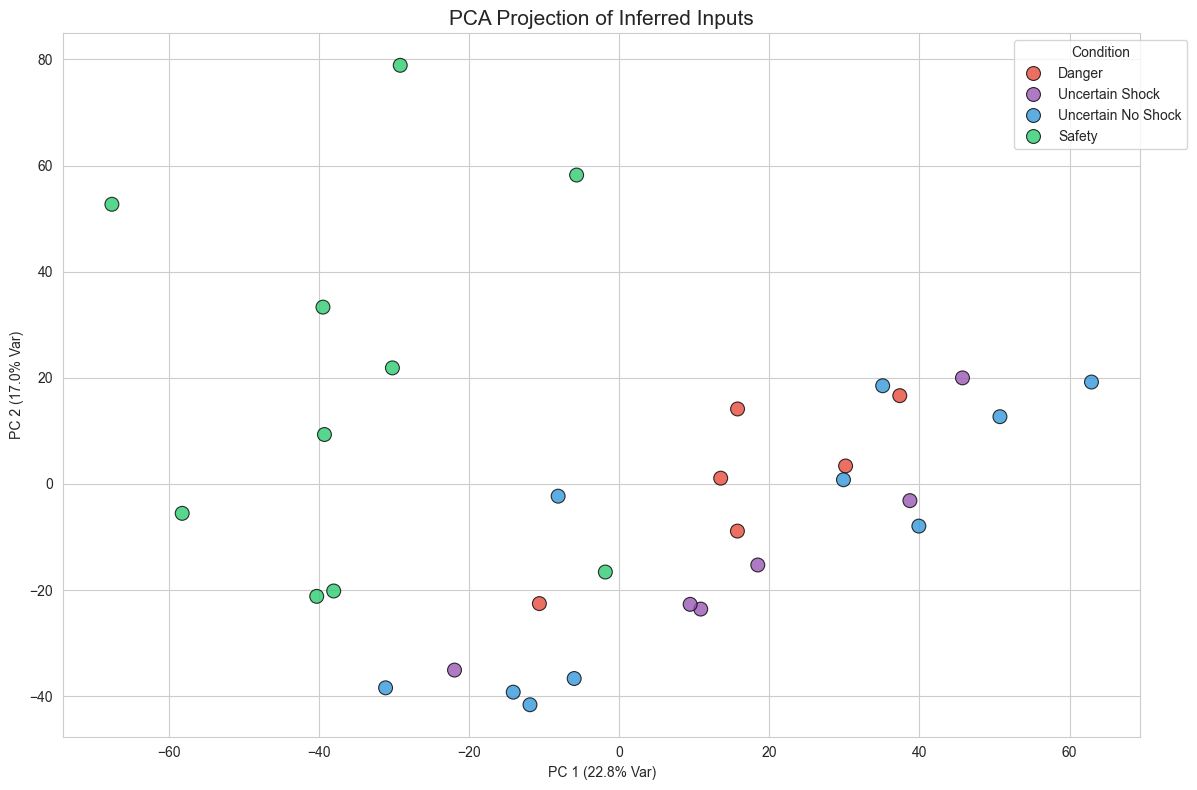

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

def plot_pca_stacked_inputs(data_array):
    """
    Reshapes data from (Trials, Time, Inputs) to (Trials * Inputs, Time)
    and performs PCA to compare with t-SNE results.
    """
    # 1. Reshape: (16, 400, 4) -> (16, 4, 400) -> (64, 400)
    n_trials, n_time, n_inputs = data_array.shape
    reshaped_data = data_array.reshape(n_trials, -1)

    # 2. Define labels for the 64 points (Same as your t-SNE script)
    base_conditions = (
        ['Danger'] * 6 + 
        ['Uncertain Shock'] * 6 + 
        ['Uncertain No Shock'] * 10 + 
        ['Safety'] * 10
    )

    # 3. Run PCA
    pca = PCA(n_components=2)
    pca_results = pca.fit_transform(reshaped_data)
    var_explained = pca.explained_variance_ratio_ * 100

    # 4. Visualization
    plt.figure(figsize=(12, 8))
    sns.set_style("whitegrid")
    
    palette = {
        'Danger': '#e74c3c', 
        'Uncertain Shock': '#9b59b6', 
        'Uncertain No Shock': '#3498db',
        'Safety': '#2ecc71'
    }

    sns.scatterplot(
        x=pca_results[:, 0], 
        y=pca_results[:, 1], 
        hue=base_conditions,
        palette=palette,
        s=100,
        alpha=0.8,
        edgecolor='black'
    )

    plt.title('PCA Projection of Inferred Inputs', fontsize=15)
    plt.xlabel(f'PC 1 ({var_explained[0]:.1f}% Var)')
    plt.ylabel(f'PC 2 ({var_explained[1]:.1f}% Var)')
    plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper right')
    plt.tight_layout()
    plt.show()

# Run the PCA comparison
plot_pca_stacked_inputs(inferred_inputs['Ctr'])

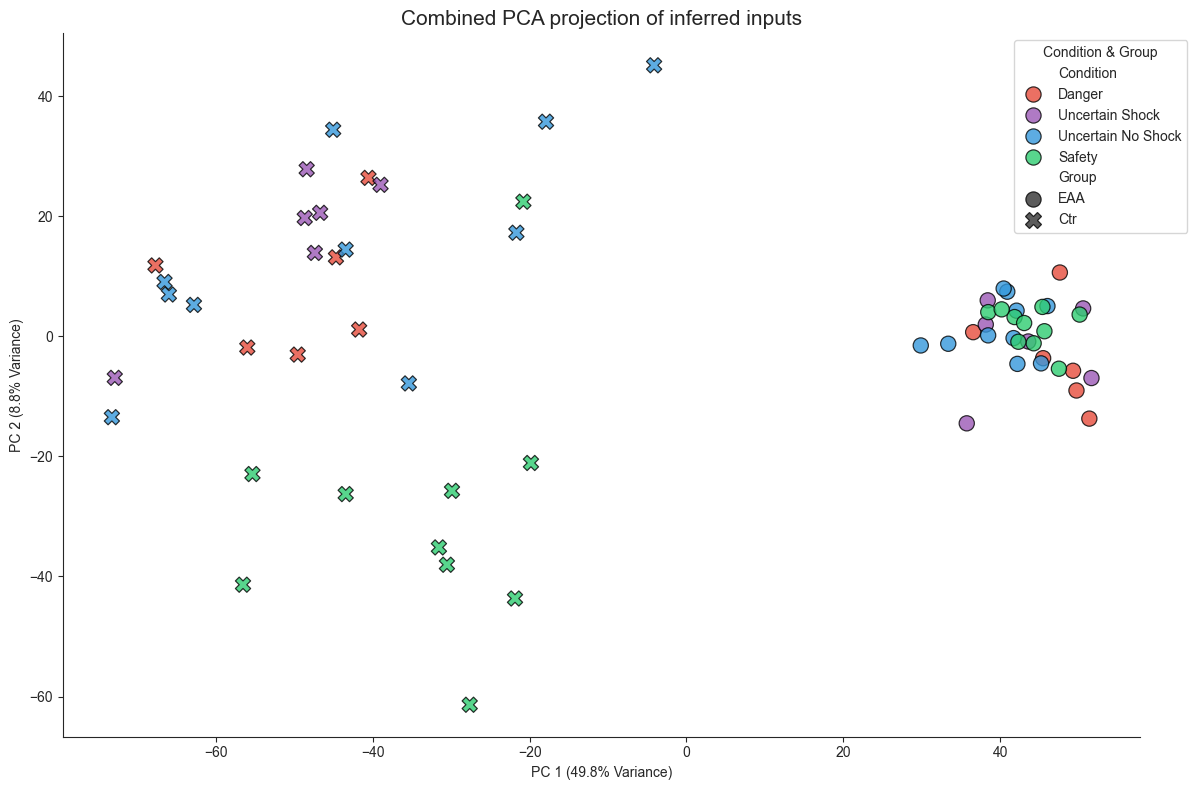

In [24]:
plot_pca_combined(inferred_inputs['EAA'][:, 125:, :], inferred_inputs['Ctr'][:, 125:, :])

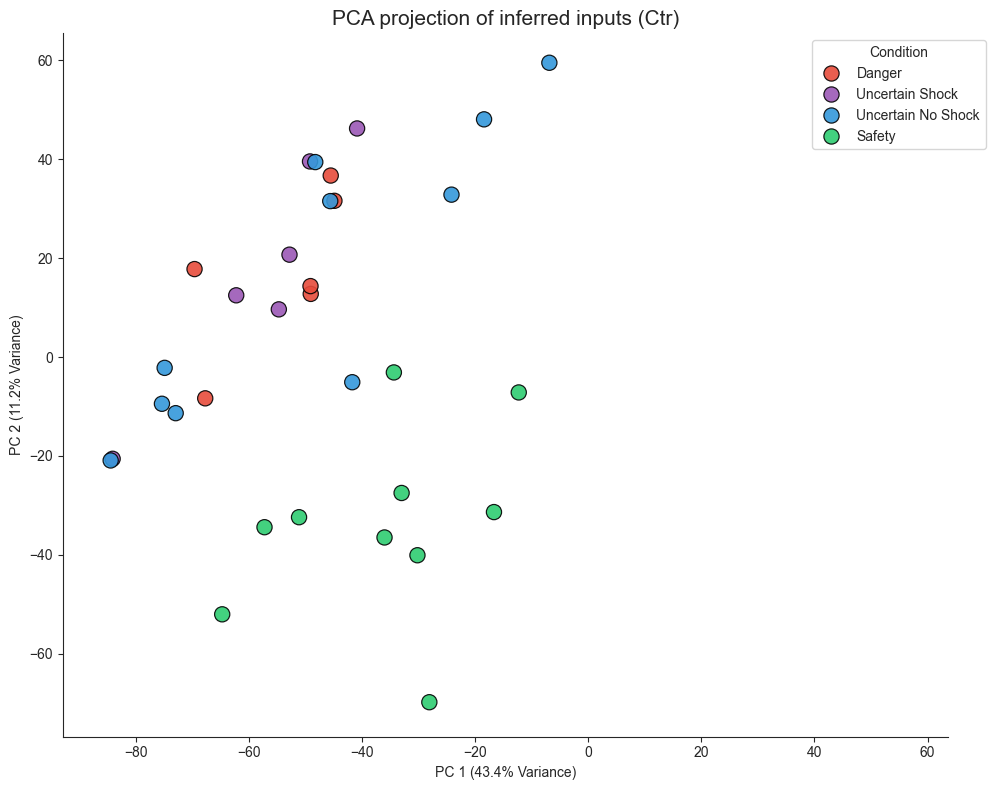

In [25]:
plot_pca(inferred_inputs['EAA'], inferred_inputs['Ctr'], title='PCA projection of inferred inputs (Ctr)', group='Ctr')

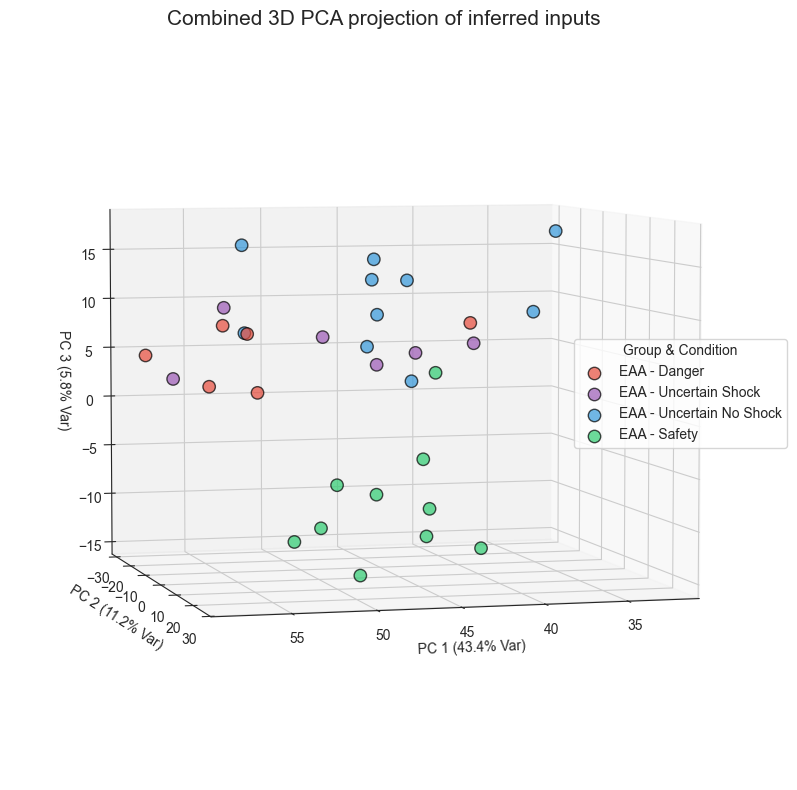

In [26]:
plot_pca_combined_3d(inferred_inputs['EAA'], inferred_inputs['Ctr'], 'Combined 3D PCA projection of inferred inputs', elev=5, azim=75)

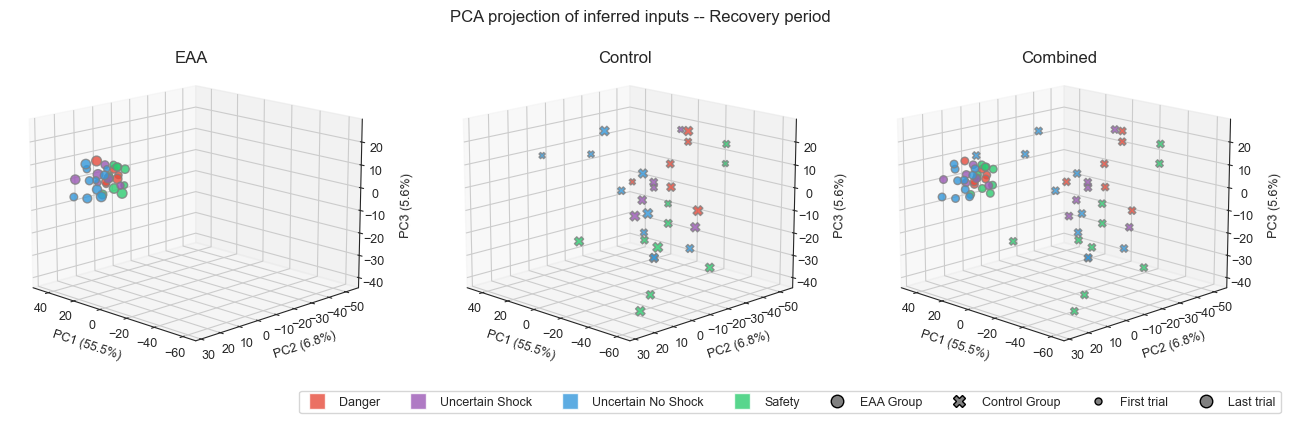

In [27]:
plot_pca_tri_panel(inferred_inputs['EAA'][:, 170:, :], inferred_inputs['Ctr'][:, 170:, :], title='PCA projection of inferred inputs -- Recovery period', elev=15, azim=135)

# Behavioural data

In [28]:
pokes_EAA = np.load('avg_poke_list_EAA.npy')[:, 30:]
pokes_Ctr = np.load('avg_poke_list_Ctr.npy')[:, 30:]
pokes_all = np.load('avg_poke_list.npy')

In [29]:
pokes_EAA.shape, pokes_Ctr.shape

((32, 70), (32, 70))

In [30]:
pokes = {
    'EAA': pokes_EAA,
    'Ctr': pokes_Ctr
}

In [31]:
factors['EAA'].shape

(32, 350, 40)

/tmp/ipykernel_3926007/2886849944.py:51: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


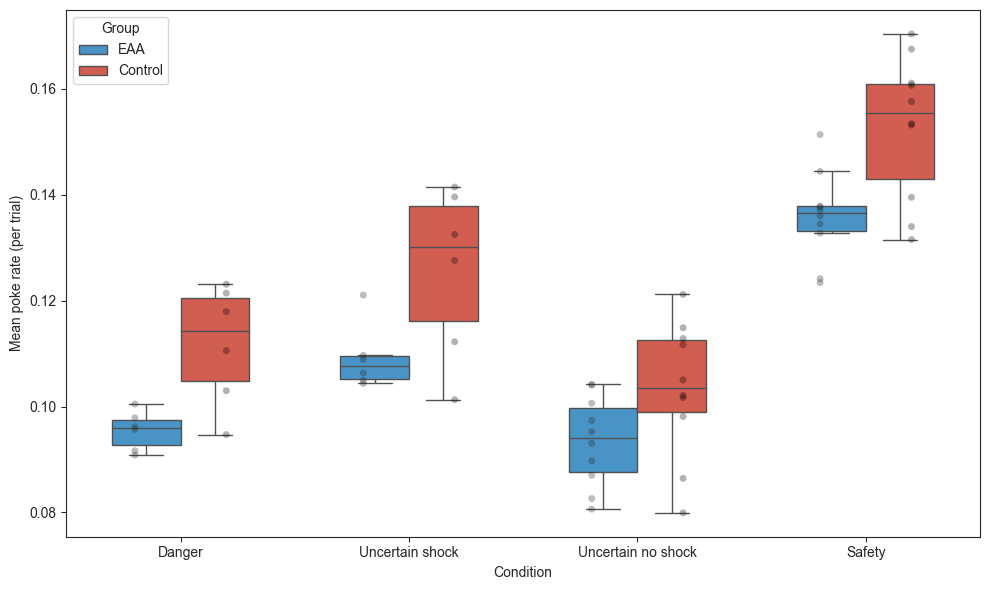

In [81]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Define the condition ranges and labels
cond_ranges = [
    (0, 6, "Danger"),
    (6, 12, "Uncertain shock"),
    (12, 22, "Uncertain no shock"),
    (22, 32, "Safety")
]

data_list = []

def process_2d_pokes(pokes_array, group_name):
    # pokes_array shape: (32, 70) -> (Trials, Time)
    for start, end, label in cond_ranges:
        # Calculate mean across time for each trial in this range
        # Result is a 1D array of trial averages (e.g., length 6 or 10)
        trial_means = pokes_array[start:end, :].mean(axis=1)
        
        for val in trial_means:
            data_list.append({
                'Condition': label,
                'Group': group_name,
                'Mean poke rate': val
            })

# Process both 2D arrays
process_2d_pokes(pokes_EAA, 'EAA')
process_2d_pokes(pokes_Ctr, 'Control')

df_compare = pd.DataFrame(data_list)

# Plotting
plt.figure(figsize=(10, 6))

# Boxplot for the distribution of trial averages
sns.boxplot(
    data=df_compare, 
    x='Condition', 
    y='Mean poke rate', 
    hue='Group', 
    palette={'EAA': '#3498db', 'Control': '#e74c3c'},
    width=0.6,
    showfliers=False
)

# Stripplot to show every single trial as a dot
sns.stripplot(
    data=df_compare, 
    x='Condition', 
    y='Mean poke rate', 
    hue='Group', 
    dodge=True, 
    color='black', 
    alpha=0.3, 
    jitter=False,
    legend=False
)

# plt.title('Trial-by-Trial Poke Rate: EAA vs Control')
plt.ylabel('Mean poke rate (per trial)')
plt.tight_layout()
plt.show()

In [55]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import (
    train_test_split,
    GroupKFold,
    GridSearchCV,
)
from sklearn.ensemble import RandomForestRegressor

n_lag = 5

cond_groups = {
    "Danger": lambda x: 0 <= x < 6,
    "Uncertain shock": lambda x: 6 <= x < 12,
    "Uncertain no shock": lambda x: 12 <= x < 22,
    "Safety": lambda x: 22 <= x < 32
}

data_types = {
    "LFADS factors": factors,
    "Smoothed spikes": spikes,
}

sessions = sorted(spikes.keys())
results = []

for cond_group, include_fn in cond_groups.items():
    for sess in sessions:
        for data_type, data in data_types.items():
            
            # --- Data Preparation & Alignment ---
            num_trials = data[sess].shape[0]
            n_t_neural = data[sess].shape[1] # 350
            n_t_pokes = pokes[sess].shape[1]  # 70
            
            trial_indices = np.arange(num_trials)
            mask = np.array([include_fn(i) for i in trial_indices])
            
            # Skip if condition has no trials in this session
            if not np.any(mask): 
                continue

            # 1. Resample Pokes for this session
            pokes_orig = pokes[sess][mask] 
            n_tr_curr = pokes_orig.shape[0]
            
            pokes_resampled = np.zeros((n_tr_curr, n_t_neural))
            x_orig = np.linspace(0, 1, n_t_pokes)
            x_new = np.linspace(0, 1, n_t_neural)
            
            for i in range(n_tr_curr):
                pokes_resampled[i] = np.interp(x_new, x_orig, pokes_orig[i])

            # 2. Align Neural and Poke data (Lagging)
            # Neural (X): (Trials, 345, Feats)
            x_curr = data[sess][mask, :-n_lag, :]
            # Pokes (Y): (Trials, 345)
            y_curr = pokes_resampled[:, n_lag:]

            # --- Within-Day Train/Test Split ---
            # We split at the trial level to ensure timepoints stay grouped
            x_train, x_test, y_train, y_test = train_test_split(
                x_curr, y_curr, test_size=0.2, random_state=42
            )

            # --- Flatten for Scikit-Learn ---
            n_tr_train, n_t_train, n_feats = x_train.shape
            x_train_flat = x_train.reshape(-1, n_feats)
            y_train_flat = y_train.reshape(-1, 1)
            
            x_test_flat = x_test.reshape(-1, n_feats)
            y_test_flat = y_test.reshape(-1, 1)

            # Define groups for GroupKFold validation
            groups = np.repeat(np.arange(n_tr_train), n_t_train)
            n_unique_trials = len(np.unique(groups))

            # Skip if we don't have enough trials for cross-validation
            if n_unique_trials < 2:
                continue
            
            # --- Model Fitting ---
            n_splits = min(4, n_unique_trials) # Using 3-fold for stability with small trial counts

            model = GridSearchCV(
            Lasso(max_iter=20000),
            param_grid={"alpha": np.logspace(-6, -1, 6)},
            cv=GroupKFold(n_splits=n_splits),
            )

            # rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)

            # param_grid = {
            #     "n_estimators": [100],         # Number of trees
            #     "max_depth": [5, 10, None],    # Limit depth to prevent overfitting on small trial counts
            #     "max_features": ["sqrt"]       # Good default for high-dimensional neural data
            # }
            
            # model = GridSearchCV(
            #     rf_model,
            #     param_grid=param_grid,
            #     cv=GroupKFold(n_splits=n_splits),
            # )
            
            # --- Model Fitting ---
            # model.fit(x_train_flat, y_train_flat.ravel(), groups=groups)
            model.fit(x_train_flat, y_train_flat, groups=groups)

            # --- Trial-by-Trial Evaluation ---
            # x_test has shape (n_test_trials, n_timesteps, n_feats)
            n_test_trials = x_test.shape[0]
            
            from sklearn.metrics import r2_score

            for t_idx in range(n_test_trials):
                # 1. Get data for this single trial
                trial_x = x_test[t_idx] # (timesteps, feats)
                trial_y = y_test[t_idx] # (timesteps, 1)
                
                # 2. Predict behavior for this trial
                trial_pred = model.predict(trial_x)
                
                # 3. Calculate R2 for this specific trial
                trial_r2 = r2_score(trial_y, trial_pred)

                # 4. Save individual trial result
                results.append({
                    "group": sess,
                    "cond_group": cond_group,
                    "session": sess,
                    "data_type": data_type,
                    "trial_id": t_idx, # Track which trial this was
                    "r2_score": trial_r2,
                })

df_results = pd.DataFrame(results)
print(df_results)

   group          cond_group session        data_type  trial_id  r2_score
0    Ctr              Danger     Ctr    LFADS factors         0  0.371847
1    Ctr              Danger     Ctr    LFADS factors         1  0.587668
2    Ctr              Danger     Ctr  Smoothed spikes         0  0.500006
3    Ctr              Danger     Ctr  Smoothed spikes         1  0.425387
4    EAA              Danger     EAA    LFADS factors         0  0.745721
5    EAA              Danger     EAA    LFADS factors         1  0.772221
6    EAA              Danger     EAA  Smoothed spikes         0  0.618607
7    EAA              Danger     EAA  Smoothed spikes         1  0.677392
8    Ctr     Uncertain shock     Ctr    LFADS factors         0  0.545390
9    Ctr     Uncertain shock     Ctr    LFADS factors         1  0.472841
10   Ctr     Uncertain shock     Ctr  Smoothed spikes         0  0.510993
11   Ctr     Uncertain shock     Ctr  Smoothed spikes         1  0.415330
12   EAA     Uncertain shock     EAA  

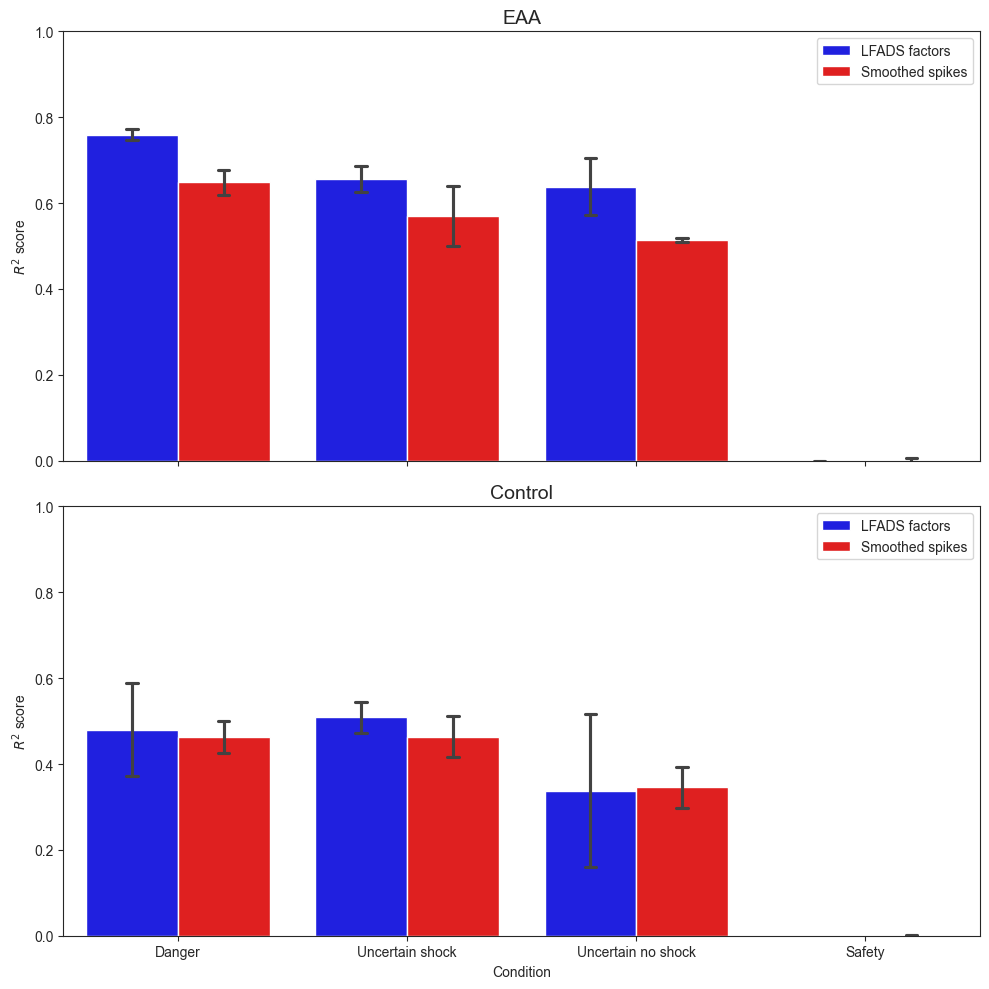

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare the DataFrame
df = pd.DataFrame(results)

# Optional: If 'group' isn't in your results, add it based on session ID
df['group'] = df['session']

# 2. Set the order for the X-axis conditions
condition_order = ["Danger", "Uncertain shock", "Uncertain no shock", "Safety"]

# 3. Create the figure with two subplots (Stacked vertically)
fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True, sharey=True)

groups = ["EAA", "Ctr"]
colors = ["blue", "red"]

for i, group in enumerate(groups):
    # Filter data for the specific group (EAA or Control)
    group_df = df[df['group'] == group]
    
    sns.barplot(
        data=group_df,
        x="cond_group",
        y="r2_score",
        hue="data_type",
        order=condition_order,
        palette=colors,
        ax=axes[i],
        capsize=.1,
        errorbar="se" # Adds standard error bars if you have multiple sessions per group
    )
    
    # Formatting
    axes[i].set_ylabel("$R^2$ score")
    axes[i].set_ylim(0, 1)
    axes[i].legend(loc="upper right")

axes[0].set_title("EAA",fontsize=14)
axes[1].set_title("Control",fontsize=14)

# Final Cleanup
axes[1].set_xlabel("Condition")
# plt.xticks(rotation=15)
plt.tight_layout()
plt.show()